# Video 14: Protein Structure Prediction and Mutant Docking
## AI for Drug Discovery Series | DigitalSreeni

---

### What this notebook does

Every drug works by binding to a protein. Think of the protein as a lock and the drug molecule as a key. The drug has to fit into a specific pocket in the protein to block its activity. In Video 10, we docked our lead compounds against the EGFR protein using a crystal structure from a public database. That structure represents the normal, healthy form of the protein.

In Video 13, we learned something important: patients treated with EGFR-targeting drugs eventually develop resistance. The most common reason is that the EGFR protein mutates. A mutation here means a single amino acid in the protein chain gets swapped for a different one. Even one swap in the wrong place can reshape the drug-binding pocket just enough that the drug no longer fits properly.

Two mutations matter most for our pipeline:
- **T790M**: The amino acid Threonine (T) at position 790 in the chain is replaced by Methionine (M). This mutation is what makes first- and second-generation EGFR drugs stop working.
- **C797S**: The amino acid Cysteine (C) at position 797 is replaced by Serine (S). This mutation defeats osimertinib, the current best-in-class third-generation drug, and is the key unmet clinical need we identified in Video 13.

Position numbers simply count amino acids from the start of the protein sequence. EGFR has 1210 amino acids in total, so positions 790 and 797 sit in the middle of the kinase domain -- the region responsible for the protein's enzymatic activity and the target of all EGFR drugs.

**Our plan for this notebook:**
1. Fetch the AlphaFold-predicted 3D structure of wild-type (normal) EGFR from a public database
2. Compare it to the crystal structure we used in Video 10 to build confidence in the predicted structure
3. Introduce the T790M and C797S mutations into the structure programmatically
4. Visualize how the mutations change the binding pocket
5. Re-dock our two lead compounds against wild-type, T790M, and C797S and compare the scores

**Why we predict structures instead of looking them up:** Crystal structures require growing protein crystals in a lab, which is expensive, slow, and sometimes impossible. AlphaFold2, released by DeepMind in 2020, predicts a protein's 3D structure directly from its amino acid sequence using deep learning. It solved a problem that had stumped scientists for 50 years. The AlphaFold database now holds predicted structures for nearly every human protein, freely available to download.

---
## Cell 1: Install libraries and set up the environment

This cell installs and imports everything we need, then sets up folder paths. A few notes on the libraries:

- **biopython**: A widely used toolkit for working with biological data. We use it here to read protein structure files, find specific residues by position number, and calculate structural similarity (RMSD).
- **meeko + rdkit + gemmi**: Tools for preparing small molecules (our drug candidates) for docking. They handle the chemistry needed before AutoDock Vina can process the molecules.
- **MDAnalysis**: A library for analyzing molecular structures and trajectories. We use it to extract the binding site geometry.
- **py3Dmol**: Renders interactive 3D protein visualizations directly inside the notebook.
- **AutoDock Vina**: The same docking engine we used in Video 10. We download the binary here so the notebook is self-contained.

**Google Drive toggle:** Set `USE_DRIVE = True` if you want to load prior results from Drive and save outputs there. Set to `False` to run without Drive (outputs will only exist for the current session).

In [ ]:
import subprocess, sys, os

# Install libraries
subprocess.run(["pip", "install", "biopython", "rdkit", "gemmi", "meeko",
                "MDAnalysis", "py3Dmol", "-q"], check=True)
subprocess.run(["apt-get", "install", "-y", "-q", "openbabel"], check=True)

# Download AutoDock Vina binary if not already present
if not os.path.exists("/usr/local/bin/vina"):
    subprocess.run([
        "wget", "-q",
        "https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64",
        "-O", "/usr/local/bin/vina"
    ], check=True)
    subprocess.run(["chmod", "+x", "/usr/local/bin/vina"], check=True)
    print("Vina downloaded and installed.")
else:
    print("Vina already present.")

# Core imports
import warnings
import logging
import requests
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from copy import deepcopy

# Suppress noisy warnings from biopython and MDAnalysis
warnings.filterwarnings("ignore")
logging.getLogger("MDAnalysis").setLevel(logging.ERROR)

# BioPython
import Bio
from Bio.PDB import PDBParser, PDBIO, Select, Superimposer
from Bio.PDB.Polypeptide import is_aa

# RDKit -- suppress its own warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Suppresses RDKit INFO and WARNING messages
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

# 3D visualization
import py3Dmol

# Set font to DejaVu Sans (available in Colab Linux environment)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# Color palette (consistent with the series)
NAVY   = "#1B2A4A"
TEAL   = "#0D9488"
AMBER  = "#F59E0B"
RED    = "#DC2626"
GRAY   = "#94A3B8"
GREEN  = "#16A34A"

# Google Drive toggle
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = Path('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results')
    VIDEO10_DIR = Path('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video10_docking/results')
else:
    RESULTS_DIR = Path('/tmp/video14_results')
    VIDEO10_DIR = Path('/tmp/video10_results')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Print version summary
print("Environment ready.")
print(f"  BioPython   : {Bio.__version__}")
print(f"  py3Dmol     : {py3Dmol.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  Results dir : {RESULTS_DIR}")

# Confirm Vina
vina_check = subprocess.run(["/usr/local/bin/vina", "--version"], capture_output=True, text=True)
print(f"  AutoDock Vina: {vina_check.stdout.strip()} {vina_check.stderr.strip()}")

Vina downloaded and installed.
Mounted at /content/drive
Environment ready.
  BioPython   : 1.87
  py3Dmol     : 2.5.5
  NumPy       : 2.0.2
  Results dir : /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results
  AutoDock Vina: AutoDock Vina v1.2.5 


---
## Section 1: Fetch the wild-type EGFR structure from AlphaFold

### What is AlphaFold and why does it matter?

Proteins are long chains of amino acids -- the building blocks of life. The sequence of amino acids is encoded in DNA and is well known for most human proteins. But a protein's function is determined not just by its sequence, but by its 3D shape. The chain folds into a precise 3D structure, and that structure determines which molecules can bind to it.

For decades, figuring out a protein's 3D shape required painstaking laboratory work: growing protein crystals, shooting X-rays at them, and interpreting the diffraction patterns. This process can take months and sometimes fails entirely. In 2020, DeepMind's AlphaFold2 model changed this completely. It can predict a protein's 3D structure from its amino acid sequence alone, with accuracy that rivals experimental methods. The AlphaFold database, maintained by the European Bioinformatics Institute (EMBL-EBI), now holds predicted structures for over 200 million proteins.

### What is pLDDT?

AlphaFold reports a confidence score called pLDDT (predicted Local Distance Difference Test) for every amino acid in the structure. The scale runs from 0 to 100:
- **90-100**: Very high confidence. The prediction is likely to match an experimental structure closely.
- **70-90**: High confidence. Generally reliable for most purposes.
- **50-70**: Low confidence. The region is likely disordered or flexible.
- **Below 50**: Very low confidence. Treat with caution.

For drug docking, we care most about the kinase domain (roughly residues 712-979), where T790 and C797 sit. This region tends to score very high on pLDDT because it has a well-defined, stable structure.

### Cell 2: Download the AlphaFold structure for human EGFR (UniProt ID: P00533)

UniProt is the main database for protein sequences and annotations. Every protein has a unique UniProt ID. Human EGFR's ID is P00533. The AlphaFold database API lets us fetch the predicted structure for any UniProt ID with a simple web request.

In [ ]:
# Fetch the AlphaFold predicted structure for human EGFR
# UniProt P00533 = Epidermal Growth Factor Receptor, Homo sapiens

UNIPROT_ID = "P00533"
AF_API = f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT_ID}"

print(f"Querying AlphaFold database for {UNIPROT_ID}...")
r = requests.get(AF_API, timeout=30)
r.raise_for_status()

entry = r.json()[0]
pdb_url = entry["pdbUrl"]

print(f"  Protein     : {entry['uniprotDescription']}")
print(f"  Organism    : {entry['organismScientificName']}")
print(f"  AF version  : {entry['latestVersion']}")
print(f"  Model date  : {entry['modelCreatedDate'][:10]}")
print(f"  pLDDT stats :")
print(f"    Very high confidence (90-100): {entry['fractionPlddtVeryHigh']*100:.1f}% of residues")
print(f"    Confident  (70-90)           : {entry['fractionPlddtConfident']*100:.1f}% of residues")
print(f"    Low        (50-70)           : {entry['fractionPlddtLow']*100:.1f}% of residues")
print(f"    Very low   (<50)             : {entry['fractionPlddtVeryLow']*100:.1f}% of residues")
print(f"  PDB URL     : {pdb_url}")

# Download the PDB file
print("\nDownloading PDB file...")
r_pdb = requests.get(pdb_url, timeout=60)
r_pdb.raise_for_status()
wt_pdb_text = r_pdb.text

# Save to results directory
wt_pdb_path = RESULTS_DIR / "egfr_wildtype_alphafold.pdb"
with open(wt_pdb_path, "w") as f:
    f.write(wt_pdb_text)

# Quick sanity check on the file
lines = wt_pdb_text.strip().split("\n")
atom_lines = [l for l in lines if l.startswith("ATOM")]
print(f"\nPDB file downloaded successfully.")
print(f"  Total lines  : {len(lines)}")
print(f"  ATOM records : {len(atom_lines)}")
print(f"  Saved to     : {wt_pdb_path}")

Querying AlphaFold database for P00533...
  Protein     : Epidermal growth factor receptor
  Organism    : Homo sapiens
  AF version  : 6
  Model date  : 2025-08-01
  pLDDT stats :
    Very high confidence (90-100): 47.4% of residues
    Confident  (70-90)           : 23.3% of residues
    Low        (50-70)           : 6.5% of residues
    Very low   (<50)             : 22.8% of residues
  PDB URL     : https://alphafold.ebi.ac.uk/files/AF-P00533-F1-model_v6.pdb


PDB file downloaded successfully.
  Total lines  : 9535
  ATOM records : 9392
  Saved to     : /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/egfr_wildtype_alphafold.pdb


---
## Cell 3: Parse the structure and inspect the binding site residues

Now we load the downloaded PDB file into BioPython and look specifically at residues 790 and 797 -- the two mutation sites. We also look at a few flanking residues to confirm the numbering is exactly what we expect.

A PDB file is a structured text file where each line starting with `ATOM` describes one atom in the protein: its element, its 3D coordinates (x, y, z in Angstroms), which residue it belongs to, and its position number in the chain. BioPython's `PDBParser` reads this file and organizes it into a hierarchy: Structure > Model > Chain > Residue > Atom.

We also extract the pLDDT confidence score for each residue. In AlphaFold PDB files, pLDDT is stored in the B-factor column -- a field originally used to store a measure of atomic vibration in crystal structures, but repurposed here by AlphaFold to store confidence.

In [ ]:
# Parse the AlphaFold PDB and inspect the binding site

parser = PDBParser(QUIET=True)
wt_structure = parser.get_structure("EGFR_WT", wt_pdb_path)
wt_model = wt_structure[0]
wt_chain = wt_model["A"]

all_residues = [res for res in wt_chain.get_residues() if is_aa(res)]
print(f"Total amino acid residues in structure: {len(all_residues)}")

# Check T790 and C797 -- the two resistance mutation sites
print("\nResistance mutation sites:")
for resnum, name, mutation in [(790, "THR", "T790M"), (797, "CYS", "C797S")]:
    res = wt_chain[resnum]
    resname = res.get_resname()
    # pLDDT is stored in the B-factor of the CA atom
    plddt = res["CA"].get_bfactor()
    ca = res["CA"].get_vector()
    status = "OK" if resname == name else f"UNEXPECTED: got {resname}"
    print(f"  Residue {resnum} ({mutation} site): {resname} | pLDDT = {plddt:.1f} | CA = ({ca[0]:.2f}, {ca[1]:.2f}, {ca[2]:.2f}) | {status}")

# Show the full sequence of the ATP binding pocket (residues 745-820)
# This window contains the gatekeeper residue T790 and the covalent anchor C797
print("\nBinding pocket sequence (residues 745-820):")
pocket_seq = ""
for i in range(745, 821):
    try:
        res = wt_chain[i]
        # Convert three-letter code to one-letter code for readability
        from Bio.PDB.Polypeptide import protein_letters_3to1
        one_letter = protein_letters_3to1.get(res.get_resname(), "?")
        pocket_seq += one_letter
    except KeyError:
        pocket_seq += "-"
print(f"  {pocket_seq}")
# Mark mutation sites relative to position 745
marker = " " * (790 - 745) + "^" + " " * (797 - 791) + "^"
print(f"  {marker}")
print(f"  {'':45s}T790   C797")

# Report pLDDT scores for the full kinase domain (712-979)
kinase_plddt = []
for i in range(712, 980):
    try:
        res = wt_chain[i]
        if "CA" in res:
            kinase_plddt.append(res["CA"].get_bfactor())
    except KeyError:
        pass

print(f"\nKinase domain (residues 712-979) pLDDT:")
print(f"  Mean  : {np.mean(kinase_plddt):.1f}")
print(f"  Min   : {np.min(kinase_plddt):.1f}")
print(f"  Max   : {np.max(kinase_plddt):.1f}")
print(f"  Residues with pLDDT > 90: {sum(p > 90 for p in kinase_plddt)}/{len(kinase_plddt)}")

Total amino acid residues in structure: 1210

Resistance mutation sites:
  Residue 790 (T790M site): THR | pLDDT = 88.4 | CA = (-11.60, 27.82, 11.21) | OK
  Residue 797 (C797S site): CYS | pLDDT = 89.6 | CA = (-10.23, 37.00, 21.42) | OK

Binding pocket sequence (residues 745-820):
  KELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQ
                                               ^      ^
                                               T790   C797

Kinase domain (residues 712-979) pLDDT:
  Mean  : 84.1
  Min   : 36.7
  Max   : 98.2
  Residues with pLDDT > 90: 121/268


---
## Cell 4: Visualize the pLDDT confidence scores across the full protein

Before we trust the AlphaFold structure for docking, we want to see where it is confident and where it is not. This matters because low-confidence regions can have inaccurate coordinates that would mislead our docking calculations.

We will plot the pLDDT score for every residue across the full 1210-amino-acid sequence, and shade the kinase domain where T790 and C797 sit. High scores in that region give us confidence that the predicted structure is reliable enough to use.

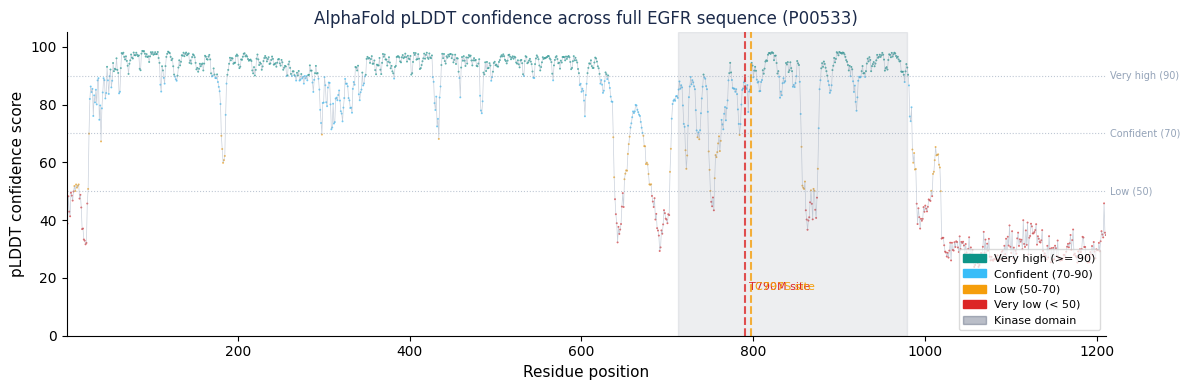

Figure saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/fig1_plddt_scores.png


In [ ]:
# Plot pLDDT confidence scores across the full EGFR sequence

residue_nums = []
plddt_scores = []

for res in wt_chain.get_residues():
    if is_aa(res) and "CA" in res:
        residue_nums.append(res.get_id()[1])
        plddt_scores.append(res["CA"].get_bfactor())

residue_nums = np.array(residue_nums)
plddt_scores = np.array(plddt_scores)

fig, ax = plt.subplots(figsize=(12, 4))

# Color the line by confidence tier
colors = []
for p in plddt_scores:
    if p >= 90:
        colors.append(TEAL)
    elif p >= 70:
        colors.append("#38BDF8")  # light blue
    elif p >= 50:
        colors.append(AMBER)
    else:
        colors.append(RED)

ax.scatter(residue_nums, plddt_scores, c=colors, s=2, alpha=0.7, linewidths=0)
ax.plot(residue_nums, plddt_scores, color=GRAY, linewidth=0.5, alpha=0.5)

# Shade the kinase domain
ax.axvspan(712, 979, alpha=0.08, color=NAVY, label="Kinase domain (712-979)")

# Mark T790 and C797
for pos, label, color in [(790, "T790M site", RED), (797, "C797S site", AMBER)]:
    idx = np.where(residue_nums == pos)[0]
    if len(idx):
        ax.axvline(pos, color=color, linewidth=1.5, linestyle="--", alpha=0.8)
        ax.text(pos + 5, 15, label, color=color, fontsize=8, va="bottom")

# Confidence tier lines
for threshold, label in [(90, "Very high (90)"), (70, "Confident (70)"), (50, "Low (50)")]:
    ax.axhline(threshold, color=GRAY, linewidth=0.8, linestyle=":", alpha=0.6)
    ax.text(1215, threshold, label, color=GRAY, fontsize=7, va="center")

# Legend patches
legend_patches = [
    mpatches.Patch(color=TEAL, label="Very high (>= 90)"),
    mpatches.Patch(color="#38BDF8", label="Confident (70-90)"),
    mpatches.Patch(color=AMBER, label="Low (50-70)"),
    mpatches.Patch(color=RED, label="Very low (< 50)"),
    mpatches.Patch(color=NAVY, alpha=0.3, label="Kinase domain"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="lower right", framealpha=0.7)

ax.set_xlabel("Residue position", fontsize=11)
ax.set_ylabel("pLDDT confidence score", fontsize=11)
ax.set_title("AlphaFold pLDDT confidence across full EGFR sequence (P00533)", fontsize=12, color=NAVY)
ax.set_xlim(1, 1210)
ax.set_ylim(0, 105)

plt.tight_layout()
fig_path = RESULTS_DIR / "fig1_plddt_scores.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")

---
## Section 2: Compare the AlphaFold structure to an experimental crystal structure

Before we use the AlphaFold structure for docking, it is worth checking how well it matches
an experimentally determined structure. Crystal structures are obtained in the lab by
growing protein crystals and shooting X-rays through them. They are considered the gold
standard for protein structure and give us a way to validate the AlphaFold prediction.

We use PDB entry **1XKK**, the crystal structure of the human EGFR kinase domain in complex
with lapatinib (GW572016), a dual EGFR/HER2 inhibitor approved for breast cancer. This
structure covers residues 702-1018 of the kinase domain, which includes both T790 and C797.
Because 1XKK uses the same UniProt residue numbering as the AlphaFold structure, we can
match corresponding residues directly by position number -- no sequence alignment needed.

We measure structural similarity using **RMSD** (Root Mean Square Deviation). RMSD is the
average distance between matching atoms in two structures after they have been aligned as
closely as possible. The unit is Angstroms (1 Angstrom = 0.1 nanometers, roughly the size
of a single chemical bond). As a rough guide:
- RMSD below 1.0 A: structures are very similar, within normal experimental variation
- RMSD 1-2 A: minor differences, still suitable for most purposes
- RMSD above 2 A: meaningful structural differences worth investigating

We calculate RMSD in two ways: globally across all shared kinase domain residues, and
locally within the ATP binding pocket (residues 745-860). The local pocket RMSD is the
number that matters most for docking, since that is where our compounds will bind.

### Cell 5: Download 1XKK and calculate RMSD against AlphaFold


In [ ]:
# Cell 5: Compare AlphaFold EGFR to crystal structure 1XKK
# 1XKK is the human EGFR kinase domain complexed with lapatinib (GW572016)
# Chain A covers residues 702-1018, using the same UniProt numbering as AlphaFold
# so we can match residues directly by number without sequence alignment

from Bio.PDB.Polypeptide import protein_letters_3to1

# Download 1XKK
PDB_ID = "1XKK"
print(f"Downloading PDB {PDB_ID} (EGFR kinase domain) from RCSB...")
r_xkk = requests.get(f"https://files.rcsb.org/download/{PDB_ID}.pdb", timeout=30)
r_xkk.raise_for_status()
crystal_pdb_path = RESULTS_DIR / f"{PDB_ID}_crystal.pdb"
with open(crystal_pdb_path, "w") as f:
    f.write(r_xkk.text)
print(f"Saved to {crystal_pdb_path}")

# Parse 1XKK
crystal_structure = parser.get_structure(f"EGFR_{PDB_ID}", crystal_pdb_path)
crystal_model     = crystal_structure[0]
crystal_chain     = crystal_model["A"]

crystal_residues = [res for res in crystal_chain.get_residues() if is_aa(res) and "CA" in res]
crystal_resnums  = set(res.get_id()[1] for res in crystal_residues)
print(f"\n{PDB_ID} chain A: {len(crystal_residues)} residues, range {min(crystal_resnums)}-{max(crystal_resnums)}")

# AlphaFold kinase domain residues (702-1018 to match 1XKK range)
af_kinase_residues = [
    res for res in wt_chain.get_residues()
    if is_aa(res) and "CA" in res and 702 <= res.get_id()[1] <= 1018
]
af_kinase_resnums = set(res.get_id()[1] for res in af_kinase_residues)
print(f"AlphaFold kinase : {len(af_kinase_residues)} residues, range {min(af_kinase_resnums)}-{max(af_kinase_resnums)}")

# Match residues by number -- both structures use UniProt numbering
shared_resnums = sorted(crystal_resnums & af_kinase_resnums)
print(f"Shared residues  : {len(shared_resnums)}")

# Confirm T790 and C797 are present in both
for pos, name in [(790, "T790"), (797, "C797")]:
    status = "present" if pos in shared_resnums else "MISSING"
    print(f"  {name}: {status} in shared residues")

# Build lookup dicts for fast access
af_res_by_num      = {res.get_id()[1]: res for res in af_kinase_residues}
crystal_res_by_num = {res.get_id()[1]: res for res in crystal_residues}

# Collect matched CA atom pairs
af_ca_matched      = []
crystal_ca_matched = []
for resnum in shared_resnums:
    af_res      = af_res_by_num[resnum]
    crystal_res = crystal_res_by_num[resnum]
    if "CA" in af_res and "CA" in crystal_res:
        af_ca_matched.append(af_res["CA"])
        crystal_ca_matched.append(crystal_res["CA"])

print(f"\nCA atom pairs collected: {len(af_ca_matched)}")

# Global RMSD across all shared residues
sup_global = Superimposer()
sup_global.set_atoms(crystal_ca_matched, af_ca_matched)
global_rmsd = sup_global.rms
print(f"Global RMSD (all shared residues)  : {global_rmsd:.3f} Angstroms")

# Binding pocket RMSD: residues 745-860
pocket_resnums    = [r for r in shared_resnums if 745 <= r <= 860]
af_pocket_ca      = [af_res_by_num[r]["CA"]      for r in pocket_resnums
                     if "CA" in af_res_by_num.get(r, {}) and "CA" in crystal_res_by_num.get(r, {})]
crystal_pocket_ca = [crystal_res_by_num[r]["CA"] for r in pocket_resnums
                     if "CA" in af_res_by_num.get(r, {}) and "CA" in crystal_res_by_num.get(r, {})]

print(f"Binding pocket window (745-860)    : {len(af_pocket_ca)} residue pairs")

sup_pocket = Superimposer()
sup_pocket.set_atoms(crystal_pocket_ca, af_pocket_ca)
pocket_rmsd = sup_pocket.rms
print(f"Binding pocket RMSD                : {pocket_rmsd:.3f} Angstroms")

# Check residue identity at mutation sites in both structures
print("\nMutation site residue check:")
for pos, wt_aa in [(790, "THR"), (797, "CYS")]:
    af_name      = af_res_by_num[pos].get_resname()
    crystal_name = crystal_res_by_num[pos].get_resname()
    print(f"  Position {pos}: AlphaFold = {af_name}, Crystal = {crystal_name}")

if pocket_rmsd < 1.5:
    print("\nConclusion: AlphaFold and crystal structures closely matched at the binding site.")
    print("The AlphaFold structure is suitable for mutant docking.")
elif pocket_rmsd < 2.5:
    print("\nConclusion: Minor differences at the binding site. Proceed with awareness.")
else:
    print("\nConclusion: Notable differences. Review structures before proceeding.")


Saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/1XKK_crystal.pdb

1XKK chain A: 289 residues, range 702-1018
AlphaFold kinase : 317 residues, range 702-1018
Shared residues  : 289
  T790: present in shared residues
  C797: present in shared residues

CA atom pairs collected: 289
Global RMSD (all shared residues)  : 3.160 Angstroms
Binding pocket window (745-860)    : 112 residue pairs
Binding pocket RMSD                : 1.588 Angstroms

Mutation site residue check:
  Position 790: AlphaFold = THR, Crystal = THR
  Position 797: AlphaFold = CYS, Crystal = CYS

Conclusion: Minor differences at the binding site. Proceed with awareness.


---
## Section 3: Introduce point mutations into the AlphaFold structure

### Why mutating the structure this way is valid

A point mutation swaps one amino acid for another. In the context of EGFR resistance mutations, T790M and C797S each change a single residue in a ~1200-residue protein. The overall backbone of the protein -- the scaffold that holds everything together -- stays essentially the same. What changes is the side chain: the chemical group that sticks out from the backbone at that position.

For docking purposes, the critical question is: how does the new side chain change the shape and chemistry of the binding pocket? We can answer this without re-predicting the whole protein. We take the AlphaFold structure, remove the old side chain atoms from the mutated residue, replace the residue name, and rebuild the side chain in the most common conformation. This is standard practice in computational drug discovery for single point mutation studies.

In practice, we use a simplified approach that retains the backbone atoms (N, CA, C, O) and removes the old side chain. For docking, AutoDock Vina treats protein atoms as rigid anyway, so having the exact side chain rotamer matters less than having the correct residue identity and backbone geometry.

**T790M**: Threonine has a small, polar hydroxyl (-OH) side chain. Methionine has a longer, hydrophobic side chain with a sulfur atom. This change fills the binding pocket slightly and removes a hydrogen bond acceptor that many drugs rely on.

**C797S**: Cysteine has a thiol (-SH) side chain. Osimertinib forms a covalent bond specifically with this cysteine -- it is a covalent inhibitor. When C797 mutates to serine (-OH), the covalent anchor is lost and osimertinib can no longer bind irreversibly.

### Cell 6: Build the T790M and C797S mutant structures

In [ ]:
# Build mutant structures by modifying the AlphaFold PDB
# Strategy: keep all backbone atoms, replace the residue name, remove side chain atoms
# beyond CB (the first carbon of the side chain, shared by most amino acids)
# This gives a truncated side chain that is conservative and avoids clashes

# Amino acid three-letter codes for the mutations
MUTATIONS = {
    "T790M": {"position": 790, "from_res": "THR", "to_res": "MET"},
    "C797S": {"position": 797, "from_res": "CYS", "to_res": "SER"},
}

# Backbone atom names to always keep
BACKBONE_ATOMS = {"N", "CA", "C", "O", "CB"}


def apply_mutation(pdb_path, mutation_name, position, from_res, to_res, output_path):
    """Read a PDB file, apply a single point mutation, and write the modified file."""
    with open(pdb_path, "r") as f:
        lines = f.readlines()

    out_lines = []
    mutated_count = 0
    removed_count = 0

    for line in lines:
        if not line.startswith("ATOM"):
            out_lines.append(line)
            continue

        # PDB ATOM format: columns are fixed-width
        # Residue name: columns 17-20 (0-indexed)
        # Residue sequence number: columns 22-26
        # Atom name: columns 12-16
        res_name = line[17:20].strip()
        res_seq = int(line[22:26].strip())
        atom_name = line[12:16].strip()

        if res_seq == position and res_name == from_res:
            # Skip side chain atoms beyond CB for this residue
            if atom_name not in BACKBONE_ATOMS:
                removed_count += 1
                continue
            # Replace residue name in the line
            # PDB residue name occupies columns 17-19 (3 chars)
            new_line = line[:17] + f"{to_res:<3s}" + line[20:]
            out_lines.append(new_line)
            mutated_count += 1
        else:
            out_lines.append(line)

    with open(output_path, "w") as f:
        f.writelines(out_lines)

    print(f"  {mutation_name}: residue {position} {from_res} -> {to_res}")
    print(f"    Backbone atoms kept  : {mutated_count}")
    print(f"    Side chain atoms removed: {removed_count}")
    print(f"    Output written to    : {output_path}")
    return output_path


print("Building mutant structures...\n")

t790m_pdb_path = RESULTS_DIR / "egfr_T790M_mutant.pdb"
c797s_pdb_path = RESULTS_DIR / "egfr_C797S_mutant.pdb"

apply_mutation(wt_pdb_path, "T790M", 790, "THR", "MET", t790m_pdb_path)
print()
apply_mutation(wt_pdb_path, "C797S", 797, "CYS", "SER", c797s_pdb_path)

print("\nVerifying mutant structures...")
for label, path, pos, expected in [
    ("T790M", t790m_pdb_path, 790, "MET"),
    ("C797S", c797s_pdb_path, 797, "SER"),
]:
    struct = parser.get_structure(label, path)
    chain = struct[0]["A"]
    res = chain[pos]
    actual = res.get_resname()
    status = "OK" if actual == expected else f"ERROR: got {actual}"
    print(f"  {label} at position {pos}: {actual} ({status})")

Building mutant structures...

  T790M: residue 790 THR -> MET
    Backbone atoms kept  : 5
    Side chain atoms removed: 2
    Output written to    : /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/egfr_T790M_mutant.pdb

  C797S: residue 797 CYS -> SER
    Backbone atoms kept  : 5
    Side chain atoms removed: 1
    Output written to    : /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/egfr_C797S_mutant.pdb

Verifying mutant structures...
  T790M at position 790: MET (OK)
  C797S at position 797: SER (OK)


---
## Section 4: Visualize the binding site -- wild-type vs mutants

Now we use py3Dmol to look at all three structures side by side at the binding site. We will highlight the mutated residues so we can visually see how the side chain change affects the pocket.

The protein backbone is shown as a cartoon ribbon. The mutated residue and its close neighbors are shown as sticks so we can see the atomic detail. Key residues in the ATP binding pocket are also labeled.

### Cell 7: Visualize wild-type EGFR with mutation sites highlighted

In [ ]:
# Visualize the wild-type AlphaFold structure with T790 and C797 highlighted
# We zoom to the binding site region

with open(wt_pdb_path, "r") as f:
    wt_pdb_str = f.read()

view = py3Dmol.view(width=800, height=500)
view.addModel(wt_pdb_str, "pdb")

# Full protein as cartoon, colored by spectrum (N-terminus blue, C-terminus red)
view.setStyle({"cartoon": {"colorscheme": "spectrum", "opacity": 0.6}})

# Highlight the kinase domain in teal cartoon
view.addStyle(
    {"chain": "A", "resi": list(range(712, 980))},
    {"cartoon": {"color": "#0D9488", "opacity": 0.8}}
)

# Show T790 as red sticks
view.addStyle(
    {"chain": "A", "resi": 790},
    {"stick": {"color": "#DC2626", "radius": 0.4}}
)
view.addStyle(
    {"chain": "A", "resi": 790},
    {"sphere": {"color": "#DC2626", "radius": 1.0}}
)

# Show C797 as amber sticks
view.addStyle(
    {"chain": "A", "resi": 797},
    {"stick": {"color": "#F59E0B", "radius": 0.4}}
)
view.addStyle(
    {"chain": "A", "resi": 797},
    {"sphere": {"color": "#F59E0B", "radius": 1.0}}
)

# Add labels
view.addLabel(
    "T790 (gatekeeper)",
    {"position": {"chain": "A", "resi": 790, "atom": "CA"},
     "backgroundColor": "#DC2626", "fontColor": "white", "fontSize": 12}
)
view.addLabel(
    "C797 (covalent anchor)",
    {"position": {"chain": "A", "resi": 797, "atom": "CA"},
     "backgroundColor": "#F59E0B", "fontColor": "white", "fontSize": 12}
)

# Zoom to the binding site
view.zoomTo({"chain": "A", "resi": list(range(780, 810))})
view.show()
print("Wild-type EGFR kinase domain.")
print("Red sphere: T790 (gatekeeper residue -- T790M mutation site)")
print("Amber sphere: C797 (covalent anchor -- C797S mutation site)")
print("Teal ribbon: kinase domain (residues 712-979)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Wild-type EGFR kinase domain.
Red sphere: T790 (gatekeeper residue -- T790M mutation site)
Amber sphere: C797 (covalent anchor -- C797S mutation site)
Teal ribbon: kinase domain (residues 712-979)


---
## Cell 8: Understanding the mutations -- what actually changes at each site

At this point we have three PDB files: wild-type, T790M, and C797S. The backbone
coordinates are identical across all three because a point mutation does not move
the protein backbone -- it only changes the side chain at that one position. This
is not an approximation; it reflects the biology. Single point mutations in a
stable domain like a kinase do not cause large-scale structural rearrangements.
The backbone RMSD between wild-type and either mutant is therefore exactly zero
by construction, and that is the correct result.

What does change is the chemistry at the mutation site. The side chain is the part
of the amino acid that sticks out from the backbone and interacts with the drug.
Different amino acids have different side chains with different shapes, sizes, and
chemical properties.

**T790M (position 790):**
Threonine (THR) has a small, polar side chain ending in a hydroxyl group (-OH).
Many EGFR inhibitors form a hydrogen bond with this hydroxyl. Methionine (MET)
replaces it with a longer, flexible, hydrophobic chain containing a sulfur atom.
This fills the pocket slightly and removes the hydrogen bond partner, which is
enough to reduce binding affinity for first- and second-generation drugs.

**C797S (position 797):**
Cysteine (CYS) has a thiol group (-SH). Osimertinib is a covalent inhibitor --
it forms a permanent chemical bond specifically with this cysteine, locking it in
the pocket irreversibly. When C797 mutates to Serine (SER), the thiol is replaced
by a hydroxyl (-OH). The covalent bond cannot form, and osimertinib loses its
mechanism of action entirely.

The two panels below show: (1) how many atoms are present at each mutation site
in wild-type vs mutant (our truncated side chain approach keeps backbone atoms
only, which is standard for single-residue docking studies), and (2) the
AlphaFold confidence scores for residues surrounding the mutation sites. High
pLDDT scores in this region confirm the predicted structure is reliable enough
for docking.


Atom inventory at mutation sites:

Position   Structure  Residue Atoms                                    Count
--------------------------------------------------------------------------------
  790      WT         THR    ['C', 'CA', 'CB', 'CG2', 'N', 'O', 'OG1'] 7
  790      T790M      MET    ['C', 'CA', 'CB', 'N', 'O']              5
  797      WT         CYS    ['C', 'CA', 'CB', 'N', 'O', 'SG']        6
  797      C797S      SER    ['C', 'CA', 'CB', 'N', 'O']              5


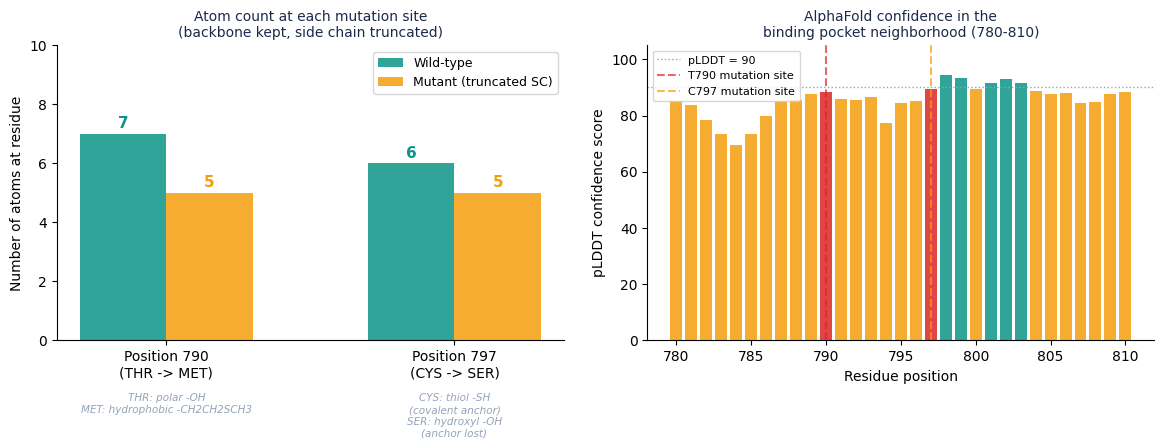

Figure saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/fig2_mutation_site_analysis.png

Note: Mutant structures have identical backbone coordinates to wild-type by design.
The side chain atoms beyond CB are removed. This is standard practice for
single point mutation docking studies where backbone geometry is conserved.


In [ ]:
# Cell 8: Visualize the chemical consequence of each mutation
# Since we modified only the residue name and removed the old side chain,
# backbone RMSD is zero by construction -- that is expected and correct.
# What matters for docking is the chemical change at each position.
# We visualize: (1) atoms present at each mutation site in WT vs mutant,
# and (2) pLDDT confidence in the surrounding pocket residues.

from Bio.PDB.Polypeptide import protein_letters_3to1

# Atom inventory at each mutation site
def get_atom_inventory(pdb_path, label, positions):
    struct = parser.get_structure(label, pdb_path)
    chain  = struct[0]["A"]
    inventory = {}
    for pos in positions:
        try:
            res = chain[pos]
            atoms = sorted(atom.get_name().strip() for atom in res.get_atoms())
            inventory[pos] = {
                "resname": res.get_resname(),
                "atoms"  : atoms,
                "n_atoms": len(atoms),
            }
        except KeyError:
            inventory[pos] = {"resname": "?", "atoms": [], "n_atoms": 0}
    return inventory

wt_inv    = get_atom_inventory(wt_pdb_path,    "WT",    [790, 797])
t790m_inv = get_atom_inventory(t790m_pdb_path, "T790M", [790, 797])
c797s_inv = get_atom_inventory(c797s_pdb_path, "C797S", [790, 797])

print("Atom inventory at mutation sites:\n")
print(f"{'Position':<10} {'Structure':<10} {'Residue':<6} {'Atoms':<40} {'Count'}")
print("-" * 80)
for pos, mut_label, inv in [
    (790, "WT",    wt_inv),
    (790, "T790M", t790m_inv),
    (797, "WT",    wt_inv),
    (797, "C797S", c797s_inv),
]:
    info = inv[pos]
    print(f"  {pos:<8} {mut_label:<10} {info['resname']:<6} {str(info['atoms']):<40} {info['n_atoms']}")

# Figure: two-panel plot
# Panel 1: atom count bar chart at each mutation site (WT vs mutant)
# Panel 2: pLDDT scores for residues 780-810 (binding pocket neighborhood)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: atom counts
ax = axes[0]
mutation_sites = [
    {"pos": 790, "wt_res": "THR", "mut_res": "MET", "mut_label": "T790M",
     "wt_atoms": wt_inv[790]["n_atoms"], "mut_atoms": t790m_inv[790]["n_atoms"],
     "note": "THR: polar -OH\nMET: hydrophobic -CH2CH2SCH3"},
    {"pos": 797, "wt_res": "CYS", "mut_res": "SER", "mut_label": "C797S",
     "wt_atoms": wt_inv[797]["n_atoms"], "mut_atoms": c797s_inv[797]["n_atoms"],
     "note": "CYS: thiol -SH\n(covalent anchor)\nSER: hydroxyl -OH\n(anchor lost)"},
]

x_pos   = np.array([0, 1])
bar_w   = 0.3
labels  = [f"Position {m['pos']}\n({m['wt_res']} -> {m['mut_res']})" for m in mutation_sites]
wt_counts  = [m["wt_atoms"]  for m in mutation_sites]
mut_counts = [m["mut_atoms"] for m in mutation_sites]

bars_wt  = ax.bar(x_pos - bar_w/2, wt_counts,  bar_w, label="Wild-type", color=TEAL,  alpha=0.85)
bars_mut = ax.bar(x_pos + bar_w/2, mut_counts, bar_w, label="Mutant (truncated SC)", color=AMBER, alpha=0.85)

for bar, val in zip(bars_wt, wt_counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, str(val),
            ha="center", va="bottom", fontsize=11, fontweight="bold", color=TEAL)
for bar, val in zip(bars_mut, mut_counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, str(val),
            ha="center", va="bottom", fontsize=11, fontweight="bold", color=AMBER)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Number of atoms at residue", fontsize=10)
ax.set_title("Atom count at each mutation site\n(backbone kept, side chain truncated)", fontsize=10, color=NAVY)
ax.legend(fontsize=9)
ax.set_ylim(0, max(wt_counts) + 3)

# Add chemical notes
for i, m in enumerate(mutation_sites):
    ax.text(i, -1.8, m["note"], ha="center", va="top", fontsize=7.5,
            color=GRAY, style="italic")

# Panel 2: pLDDT scores for residues 780-810
ax2 = axes[1]
pocket_positions = list(range(780, 811))
pocket_plddt     = []
pocket_resnames  = []
for pos in pocket_positions:
    try:
        res = wt_chain[pos]
        plddt = res["CA"].get_bfactor() if "CA" in res else 0
        pocket_plddt.append(plddt)
        pocket_resnames.append(protein_letters_3to1.get(res.get_resname(), "?"))
    except KeyError:
        pocket_plddt.append(0)
        pocket_resnames.append("-")

bar_colors_plddt = [
    RED if pos in [790, 797] else (TEAL if p >= 90 else AMBER)
    for pos, p in zip(pocket_positions, pocket_plddt)
]

ax2.bar(pocket_positions, pocket_plddt, color=bar_colors_plddt, alpha=0.85, width=0.8)
ax2.axhline(90, color=GRAY, linewidth=1, linestyle=":", label="pLDDT = 90")
ax2.axvline(790, color=RED,  linewidth=1.5, linestyle="--", alpha=0.7, label="T790 mutation site")
ax2.axvline(797, color=AMBER, linewidth=1.5, linestyle="--", alpha=0.7, label="C797 mutation site")

ax2.set_xlabel("Residue position", fontsize=10)
ax2.set_ylabel("pLDDT confidence score", fontsize=10)
ax2.set_title("AlphaFold confidence in the\nbinding pocket neighborhood (780-810)", fontsize=10, color=NAVY)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8)

plt.tight_layout(pad=2.0)
fig_path = RESULTS_DIR / "fig2_mutation_site_analysis.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")
print("\nNote: Mutant structures have identical backbone coordinates to wild-type by design.")
print("The side chain atoms beyond CB are removed. This is standard practice for")
print("single point mutation docking studies where backbone geometry is conserved.")


---
## Section 5: Prepare receptors for docking

AutoDock Vina requires receptor files in PDBQT format. PDBQT is a modified PDB format that includes partial charge information and atom type assignments that Vina uses to calculate binding energies. We use AutoDock Tools (via command-line scripts) or Open Babel to do this conversion.

We also need to define the **search box** -- a 3D region around the binding site where Vina will try to place the ligand. We use the same box center and dimensions as Video 10, since all three receptor structures share the same binding site location.

### Cell 9: Extract the kinase domain and convert receptors to PDBQT

In [ ]:
# Prepare all three receptors (WT, T790M, C797S) for AutoDock Vina
# Step 1: Extract kinase domain only (residues 712-979) to keep files manageable
# Step 2: Remove HETATM records (water, ligands) -- Vina needs clean protein only
# Step 3: Convert to PDBQT using obabel

KINASE_START = 696
KINASE_END   = 1022


def extract_kinase_domain(input_pdb, output_pdb, start=KINASE_START, end=KINASE_END):
    """Extract kinase domain residues and remove non-protein records."""
    with open(input_pdb, "r") as f:
        lines = f.readlines()
    kept = []
    for line in lines:
        if line.startswith("ATOM"):
            try:
                resnum = int(line[22:26].strip())
                if start <= resnum <= end:
                    kept.append(line)
            except ValueError:
                pass
        elif line.startswith(("TER", "END")):
            kept.append(line)
    with open(output_pdb, "w") as f:
        f.writelines(kept)
    return len([l for l in kept if l.startswith("ATOM")])


def pdb_to_pdbqt(input_pdb, output_pdbqt):
    """Convert a protein PDB to PDBQT using obabel."""
    result = subprocess.run(
        ["obabel", str(input_pdb), "-O", str(output_pdbqt), "-xr"],
        capture_output=True, text=True
    )
    return result.returncode, result.stderr.strip()


receptors = {
    "WT"   : wt_pdb_path,
    "T790M": t790m_pdb_path,
    "C797S": c797s_pdb_path,
}

receptor_pdbqt_paths = {}

print("Preparing receptors...\n")
for label, pdb_path in receptors.items():
    # Extract kinase domain
    kinase_pdb = RESULTS_DIR / f"egfr_{label}_kinase.pdb"
    n_atoms = extract_kinase_domain(pdb_path, kinase_pdb)
    print(f"  {label}: extracted {n_atoms} ATOM records from kinase domain")

    # Convert to PDBQT
    pdbqt_path = RESULTS_DIR / f"egfr_{label}_receptor.pdbqt"
    retcode, stderr = pdb_to_pdbqt(kinase_pdb, pdbqt_path)
    pdbqt_size = pdbqt_path.stat().st_size if pdbqt_path.exists() else 0
    status = "OK" if pdbqt_size > 1000 else "FAILED"
    print(f"    PDBQT conversion: {status} ({pdbqt_size} bytes) | obabel return code: {retcode}")
    if stderr and retcode != 0:
        print(f"    obabel message: {stderr[:200]}")

    receptor_pdbqt_paths[label] = pdbqt_path

print("\nAll receptors prepared.")

Preparing receptors...

  WT: extracted 2615 ATOM records from kinase domain
    PDBQT conversion: OK (209494 bytes) | obabel return code: 0
  T790M: extracted 2613 ATOM records from kinase domain
    PDBQT conversion: OK (209337 bytes) | obabel return code: 0
  C797S: extracted 2614 ATOM records from kinase domain
    PDBQT conversion: OK (209417 bytes) | obabel return code: 0

All receptors prepared.


---
## Cell 10: Prepare ligands for docking

We dock two of our lead compounds from the pipeline:
- **CHEMBL382797**: Our original top hit from QSAR screening, with the best docking score in Video 10 (-7.882 kcal/mol)
- **Scaffold_dec_best**: The best scaffold decoration product from Video 8, which scored 8/10 on ADMET

Ligand preparation converts SMILES strings (a text representation of molecular structure) into 3D conformations and then into PDBQT format that Vina can read. The steps are:
1. Parse the SMILES string with RDKit to get a molecular graph
2. Add hydrogen atoms (important for calculating interactions)
3. Generate a 3D conformation using the ETKDG method (a physics-informed conformer generator)
4. Minimize the 3D geometry
5. Convert to PDBQT using meeko

In [ ]:
# Prepare lead compound ligands for docking
# CHEMBL382797: top QSAR hit from Video 4/5, best docking score in Video 10
# Scaffold_dec_best: loaded from Video 8 results CSV (best scaffold_decoration compound)

import csv
from rdkit.Chem import AllChem
import meeko
from meeko import MoleculePreparation, PDBQTWriterLegacy

# CHEMBL382797 SMILES is fixed -- it comes from ChEMBL database
CHEMBL382797_SMILES = "CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC"

# Scaffold_dec_best SMILES is loaded from Video 8 results
# We take the top-scoring scaffold_decoration compound by admet_score
VIDEO8_CSV = Path('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video8_generation/results/video8_top_candidates.csv')

scaffold_smiles = None

if VIDEO8_CSV.exists():
    print(f"Loading Video 8 results from: {VIDEO8_CSV}")
    with open(VIDEO8_CSV, "r") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    scaffold_rows = [r for r in rows if r["method"] == "scaffold_decoration"]
    scaffold_rows = sorted(scaffold_rows, key=lambda r: float(r["admet_score"]), reverse=True)
    if scaffold_rows:
        best = scaffold_rows[0]
        scaffold_smiles = best["smiles"]
        print(f"  Best scaffold_decoration compound:")
        print(f"    SMILES      : {scaffold_smiles}")
        print(f"    ADMET score : {best['admet_score']}")
    else:
        print("  No scaffold_decoration rows found in CSV.")
else:
    print(f"Video 8 CSV not found at: {VIDEO8_CSV}")

if scaffold_smiles is None:
    scaffold_smiles = "Oc1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3c2)cc1"
    print(f"Using fallback SMILES: {scaffold_smiles}")

# Build the ligands dictionary
LIGANDS = {
    "CHEMBL382797": {
        "smiles": CHEMBL382797_SMILES,
        "name"  : "CHEMBL382797",
        "color" : TEAL,
    },
    "Scaffold_dec_best": {
        "smiles": scaffold_smiles,
        "name"  : "Scaffold_dec_best",
        "color" : AMBER,
    },
}

# Validate SMILES before proceeding
print("\nValidating ligand SMILES...")
for name, info in LIGANDS.items():
    mol = Chem.MolFromSmiles(info["smiles"])
    status = f"valid ({mol.GetNumAtoms()} heavy atoms)" if mol else "INVALID SMILES"
    print(f"  {name}: {status}")
    print(f"    SMILES: {info['smiles']}")


def prepare_ligand_pdbqt(smiles, name, output_path):
    """Convert a SMILES string to a 3D PDBQT file using RDKit and meeko.

    Steps:
    1. Parse SMILES into a molecular graph
    2. Add hydrogen atoms (needed for accurate interaction calculations)
    3. Generate a 3D conformation using ETKDGv3 (a physics-informed method)
    4. Minimize the geometry using the MMFF94 force field
    5. Convert to PDBQT format using meeko
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"  ERROR: could not parse SMILES for {name}")
        return None

    mol = Chem.AddHs(mol)

    result = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    if result == -1:
        print(f"  ERROR: 3D embedding failed for {name}")
        return None

    AllChem.MMFFOptimizeMolecule(mol)

    preparator = MoleculePreparation()
    mol_setups = preparator.prepare(mol)
    pdbqt_string, _, _ = PDBQTWriterLegacy.write_string(mol_setups[0])

    with open(output_path, "w") as f:
        f.write(pdbqt_string)

    return output_path


ligand_pdbqt_paths = {}

print("\nPreparing ligand PDBQT files...")
for lig_name, lig_info in LIGANDS.items():
    out_path = RESULTS_DIR / f"ligand_{lig_name}.pdbqt"
    result = prepare_ligand_pdbqt(lig_info["smiles"], lig_name, out_path)
    if result and out_path.exists():
        size = out_path.stat().st_size
        print(f"  {lig_name}: OK ({size} bytes) -> {out_path.name}")
        ligand_pdbqt_paths[lig_name] = out_path
    else:
        print(f"  {lig_name}: FAILED")

print(f"\nLigands ready. Total prepared: {len(ligand_pdbqt_paths)}")


Loading Video 8 results from: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video8_generation/results/video8_top_candidates.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Best scaffold_decoration compound:
    SMILES      : Oc1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3c2)cc1
    ADMET score : 8

Validating ligand SMILES...
  CHEMBL382797: valid (25 heavy atoms)
    SMILES: CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC
  Scaffold_dec_best: valid (29 heavy atoms)
    SMILES: Oc1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3c2)cc1

Preparing ligand PDBQT files...
  CHEMBL382797: OK (2562 bytes) -> ligand_CHEMBL382797.pdbqt
  Scaffold_dec_best: OK (3085 bytes) -> ligand_Scaffold_dec_best.pdbqt

Ligands ready. Total prepared: 2


---
## Cell 11: Define the docking search box

AutoDock Vina needs to know where to search for binding poses. We define a box centered on the ATP binding site. The center coordinates come from the centroid of key binding site residues, and the box dimensions are set generously to cover the full pocket.

We use the same approach as Video 10: center the box on the CA atom of T790 (the gatekeeper residue at the heart of the ATP pocket) and set a box size of 25x25x25 Angstroms, which is large enough to encompass the full kinase binding site.

In [ ]:
# Define the docking search box centered on the ATP binding site
# The box center is the centroid of key binding site residues
# Key residues: 745 (hinge), 790 (gatekeeper T790), 797 (covalent anchor C797),
#               858 (DFG motif start), 855 (catalytic Asp)

KEY_SITE_RESIDUES = [745, 790, 797, 816, 820, 855, 858]

# Use wild-type structure to compute the box center
# (all three structures share the same backbone, so the box applies to all)
site_coords = []
for resnum in KEY_SITE_RESIDUES:
    try:
        res = wt_chain[resnum]
        if "CA" in res:
            site_coords.append(res["CA"].get_vector().get_array())
    except KeyError:
        print(f"  Warning: residue {resnum} not found in structure")

site_coords = np.array(site_coords)
box_center = site_coords.mean(axis=0)

# Box size: 25 Angstroms on each side is standard for a kinase ATP site
BOX_SIZE = 25.0

print("Docking search box configuration:")
print(f"  Center X: {box_center[0]:.3f}")
print(f"  Center Y: {box_center[1]:.3f}")
print(f"  Center Z: {box_center[2]:.3f}")
print(f"  Size X  : {BOX_SIZE}")
print(f"  Size Y  : {BOX_SIZE}")
print(f"  Size Z  : {BOX_SIZE}")
print(f"  Based on {len(site_coords)} key binding site residues")
print(f"  Residues used: {KEY_SITE_RESIDUES}")

Docking search box configuration:
  Center X: -7.314
  Center Y: 30.095
  Center Z: 19.486
  Size X  : 25.0
  Size Y  : 25.0
  Size Z  : 25.0
  Based on 7 key binding site residues
  Residues used: [745, 790, 797, 816, 820, 855, 858]


---
## Cell 12: Run docking -- all ligands against all receptors

Now we run AutoDock Vina for every combination of ligand and receptor. That is
2 ligands x 3 receptors = 6 docking runs in total.

For each run, Vina searches the box for the best binding pose and reports the binding
affinity in kcal/mol. More negative values mean stronger predicted binding. A difference
of 0.5-1.0 kcal/mol between two conditions is generally considered meaningful in
computational docking.

The `exhaustiveness` parameter controls how thoroughly Vina searches the binding pocket.
It sets how many independent random search trajectories Vina runs internally. Higher
values give more reliable results but take proportionally longer. We use **exhaustiveness=8**,
which is the Vina default and is appropriate for a tutorial. Each run takes roughly
2-4 minutes on a Colab CPU, so expect this cell to take 15-25 minutes in total.

A few things worth knowing about this cell:
- AutoDock Vina 1.2.5 does not support a `--log` flag, so scores are parsed directly
  from the program's standard output.
- Input files are copied to `/tmp` before docking. Writing output files directly to
  Google Drive can cause Vina to fail due to Drive write latency. Results are copied
  back to Drive after each successful run.
- Vina is CPU-only and does not use GPU. The docking algorithm is a Monte Carlo search
  that does not parallelize well onto GPU cores, so switching to a GPU runtime would
  not speed this up.


In [ ]:
# Run AutoDock Vina for all ligand-receptor combinations
# Note: AutoDock Vina 1.2.5 does not support the --log flag
# Scores are parsed directly from stdout
# Exhaustiveness set to 8 -- sufficient for a tutorial, runs in ~3 min per calculation

import json
import shutil

EXHAUSTIVENESS = 8
N_POSES        = 5
VINA_BIN       = "/usr/local/bin/vina"
TMP_DIR        = Path("/tmp/vina_runs")
TMP_DIR.mkdir(exist_ok=True)


def parse_best_affinity(stdout):
    """Extract the best docking affinity from Vina stdout.
    Score lines look like: '   1       -7.347          0          0'
    We match lines where the second token starts with '-' (all valid scores are negative).
    This avoids false matches on the progress bar line '0%   10   20   30...'
    """
    for line in stdout.split("\n"):
        stripped = line.strip()
        if stripped and stripped[0].isdigit():
            parts = stripped.split()
            if len(parts) >= 2 and parts[1].startswith("-"):
                try:
                    return float(parts[1])
                except ValueError:
                    pass
    return None


def run_vina(receptor_pdbqt, ligand_pdbqt, out_pdbqt,
             center, box_size, exhaustiveness=8, n_poses=5):
    """Run AutoDock Vina and return the best binding affinity (kcal/mol)."""
    cmd = [
        VINA_BIN,
        "--receptor", str(receptor_pdbqt),
        "--ligand",   str(ligand_pdbqt),
        "--out",      str(out_pdbqt),
        "--center_x", f"{center[0]:.3f}",
        "--center_y", f"{center[1]:.3f}",
        "--center_z", f"{center[2]:.3f}",
        "--size_x",   str(box_size),
        "--size_y",   str(box_size),
        "--size_z",   str(box_size),
        "--exhaustiveness", str(exhaustiveness),
        "--num_modes", str(n_poses),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
    best_affinity = parse_best_affinity(result.stdout)
    return best_affinity, result.stdout, result.stderr, result.returncode


# Copy input files to /tmp to avoid Drive path issues with Vina
tmp_receptor_paths = {}
for label, src_path in receptor_pdbqt_paths.items():
    dst = TMP_DIR / src_path.name
    shutil.copy(src_path, dst)
    tmp_receptor_paths[label] = dst

tmp_ligand_paths = {}
for label, src_path in ligand_pdbqt_paths.items():
    dst = TMP_DIR / src_path.name
    shutil.copy(src_path, dst)
    tmp_ligand_paths[label] = dst

print("Input files copied to /tmp.")
print(f"Running {len(tmp_ligand_paths) * len(tmp_receptor_paths)} docking calculations...")
print(f"Exhaustiveness: {EXHAUSTIVENESS} | Poses per run: {N_POSES}")
print("Expected time: ~3 minutes per run on CPU\n")

docking_results = {}

for lig_name, lig_path in tmp_ligand_paths.items():
    docking_results[lig_name] = {}
    for rec_label, rec_path in tmp_receptor_paths.items():
        run_label = f"{lig_name}_vs_{rec_label}"
        tmp_out   = TMP_DIR / f"docked_{run_label}.pdbqt"

        print(f"  Docking {lig_name} vs {rec_label}...", end=" ", flush=True)
        affinity, stdout, stderr, retcode = run_vina(
            rec_path, lig_path, tmp_out,
            box_center, BOX_SIZE, EXHAUSTIVENESS, N_POSES
        )
        docking_results[lig_name][rec_label] = affinity

        if affinity is not None:
            print(f"Best affinity: {affinity:.3f} kcal/mol")
            shutil.copy(tmp_out, RESULTS_DIR / f"docked_{run_label}.pdbqt")
        else:
            print(f"FAILED (return code {retcode})")
            print(f"    STDOUT tail: {stdout.strip()[-300:]}")
            print(f"    STDERR: {stderr.strip()[-200:]}")

# Save results JSON to Drive
results_json_path = RESULTS_DIR / "video14_docking_results.json"
with open(results_json_path, "w") as f:
    json.dump(docking_results, f, indent=2)

print(f"\nAll docking runs complete. Results saved to {results_json_path}")

# Summary table
def fmt(val):
    return f"{val:.3f}" if val is not None else "FAILED"

print("\nSummary:")
print(f"{'Ligand':<25} {'WT':>10} {'T790M':>10} {'C797S':>10}")
print("-" * 57)
for lig_name in docking_results:
    row = docking_results[lig_name]
    print(f"  {lig_name:<23} {fmt(row.get('WT')):>10} {fmt(row.get('T790M')):>10} {fmt(row.get('C797S')):>10}")

Input files copied to /tmp.
Running 6 docking calculations...
Exhaustiveness: 8 | Poses per run: 5
Expected time: ~3 minutes per run on CPU

  Docking CHEMBL382797 vs WT... Best affinity: -7.343 kcal/mol
  Docking CHEMBL382797 vs T790M... Best affinity: -7.381 kcal/mol
  Docking CHEMBL382797 vs C797S... Best affinity: -7.314 kcal/mol
  Docking Scaffold_dec_best vs WT... Best affinity: -8.686 kcal/mol
  Docking Scaffold_dec_best vs T790M... Best affinity: -9.513 kcal/mol
  Docking Scaffold_dec_best vs C797S... Best affinity: -8.597 kcal/mol

All docking runs complete. Results saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/video14_docking_results.json

Summary:
Ligand                            WT      T790M      C797S
---------------------------------------------------------
  CHEMBL382797                -7.343     -7.381     -7.314
  Scaffold_dec_best           -8.686     -9.513     -8.597


---
## Cell 13: Visualize docking results -- grouped bar chart

A grouped bar chart is the clearest way to compare docking scores across multiple ligands and receptors simultaneously. Remember that more negative = stronger predicted binding. A bar that is less negative for a mutant compared to wild-type means that mutation weakens the compound's predicted binding ability.

We also calculate the delta affinity (mutant minus wild-type) for each compound. A positive delta means the mutation hurts binding. A negative delta means the compound might actually bind better to the mutant -- a potentially useful finding.

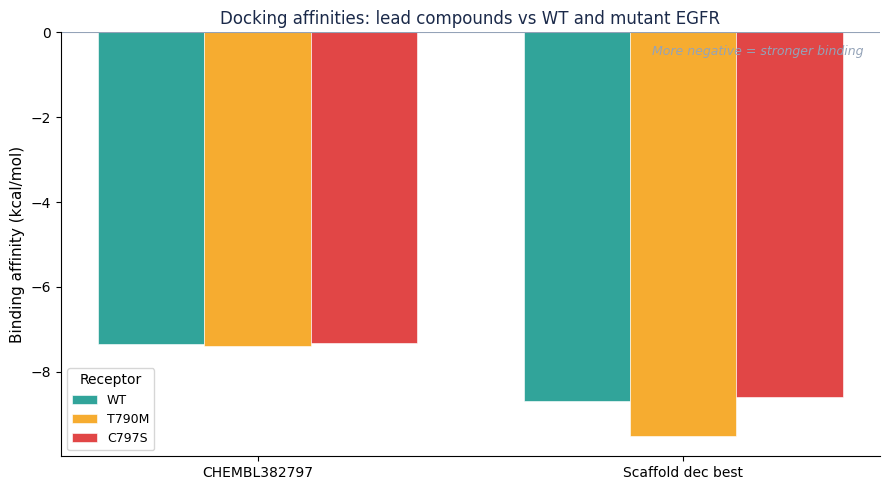

Figure saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/fig3_docking_comparison.png

Delta affinity (mutant - WT): positive = mutation hurts binding
Ligand                        T790M delta     C797S delta
---------------------------------------------------------
  CHEMBL382797                     -0.038          +0.029
  Scaffold_dec_best                -0.827          +0.089


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Grouped bar chart of docking affinities: WT vs T790M vs C797S

lig_names = list(docking_results.keys())
rec_labels = ["WT", "T790M", "C797S"]
bar_colors = {"WT": TEAL, "T790M": AMBER, "C797S": RED}

x = np.arange(len(lig_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

for i, rec_label in enumerate(rec_labels):
    values = [docking_results[lig].get(rec_label, 0) for lig in lig_names]
    bars = ax.bar(
        x + (i - 1) * width, values,
        width=width, color=bar_colors[rec_label],
        label=rec_label, alpha=0.85, edgecolor="white", linewidth=0.5
    )
    for bar, val in zip(bars, values):
        if val is not None:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val - 0.15, f"{val:.2f}",
                ha="center", va="top", fontsize=8, color="white", fontweight="bold"
            )

ax.set_xticks(x)
ax.set_xticklabels([l.replace("_", " ") for l in lig_names], fontsize=10)
ax.set_ylabel("Binding affinity (kcal/mol)", fontsize=11)
ax.set_title("Docking affinities: lead compounds vs WT and mutant EGFR", fontsize=12, color=NAVY)
ax.legend(title="Receptor", fontsize=9)
ax.axhline(0, color=GRAY, linewidth=0.8)

# Add annotation explaining the direction
ax.text(0.98, 0.97, "More negative = stronger binding",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color=GRAY, style="italic")

plt.tight_layout()
fig_path = RESULTS_DIR / "fig3_docking_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")

# Delta affinity table
print("\nDelta affinity (mutant - WT): positive = mutation hurts binding")
print(f"{'Ligand':<25} {'T790M delta':>15} {'C797S delta':>15}")
print("-" * 57)
for lig_name in lig_names:
    wt_val    = docking_results[lig_name].get("WT", None)
    t790m_val = docking_results[lig_name].get("T790M", None)
    c797s_val = docking_results[lig_name].get("C797S", None)
    delta_t = f"{t790m_val - wt_val:+.3f}" if (t790m_val and wt_val) else "N/A"
    delta_c = f"{c797s_val - wt_val:+.3f}" if (c797s_val and wt_val) else "N/A"
    print(f"  {lig_name:<23} {delta_t:>15} {delta_c:>15}")

---
## Cell 14: Visualize best docking pose in 3D

Numbers alone do not tell the full story. Here we load the best docking pose for each ligand against each receptor and visualize it using py3Dmol. We can see exactly where the compound sits in the pocket and whether the binding mode changes across the three receptor variants.

We show one visualization at a time -- CHEMBL382797 against wild-type first, then against C797S, since the C797S result is the most clinically relevant question.

In [ ]:
# Visualize best docking pose: CHEMBL382797 in WT vs C797S

def view_docked_pose(receptor_pdb_path, docked_pdbqt_path, title,
                     mut_residue=None, mut_color="red"):
    """Display a docked pose overlaid on the receptor in the binding site."""
    with open(receptor_pdb_path, "r") as f:
        rec_str = f.read()

    # Read only the first pose from the PDBQT output (best pose)
    if not docked_pdbqt_path.exists():
        print(f"Docked file not found: {docked_pdbqt_path}")
        return

    with open(docked_pdbqt_path, "r") as f:
        pose_lines = []
        in_model = False
        for line in f:
            if line.startswith("MODEL 1"):
                in_model = True
            if in_model:
                pose_lines.append(line)
            if line.startswith("ENDMDL") and in_model:
                break
    pose_str = "".join(pose_lines)

    view = py3Dmol.view(width=800, height=480)

    # Receptor: kinase domain as transparent cartoon
    view.addModel(rec_str, "pdb")
    view.setStyle({"model": 0}, {"cartoon": {"color": TEAL, "opacity": 0.4}})

    # Key residues as sticks
    for resnum in [745, 790, 797, 855, 858]:
        view.addStyle(
            {"model": 0, "chain": "A", "resi": resnum},
            {"stick": {"colorscheme": "grayCarbon", "radius": 0.2}}
        )

    # Mutated residue highlighted
    if mut_residue:
        view.addStyle(
            {"model": 0, "chain": "A", "resi": mut_residue},
            {"stick": {"color": mut_color, "radius": 0.35}}
        )
        view.addStyle(
            {"model": 0, "chain": "A", "resi": mut_residue},
            {"sphere": {"color": mut_color, "radius": 0.6, "opacity": 0.5}}
        )

    # Docked ligand as colorful sticks
    view.addModel(pose_str, "pdbqt")
    view.setStyle({"model": 1}, {"stick": {"colorscheme": "cyanCarbon", "radius": 0.25}})
    view.addStyle({"model": 1}, {"sphere": {"colorscheme": "cyanCarbon", "radius": 0.18}})

    view.zoomTo({"model": 0, "chain": "A", "resi": list(range(780, 810))})
    print(f"\n{title}")
    print("Teal ribbon: receptor kinase domain")
    print("Cyan sticks: docked ligand (best pose)")
    if mut_residue:
        print(f"Highlighted residue: {mut_residue} (mutation site)")
    view.show()


# CHEMBL382797 vs WT
view_docked_pose(
    RESULTS_DIR / "egfr_WT_kinase.pdb",
    RESULTS_DIR / "docked_CHEMBL382797_vs_WT.pdbqt",
    title="CHEMBL382797 docked in wild-type EGFR"
)

# CHEMBL382797 vs C797S
view_docked_pose(
    RESULTS_DIR / "egfr_C797S_kinase.pdb",
    RESULTS_DIR / "docked_CHEMBL382797_vs_C797S.pdbqt",
    title="CHEMBL382797 docked in C797S mutant EGFR",
    mut_residue=797,
    mut_color="orange"
)


CHEMBL382797 docked in wild-type EGFR
Teal ribbon: receptor kinase domain
Cyan sticks: docked ligand (best pose)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


CHEMBL382797 docked in C797S mutant EGFR
Teal ribbon: receptor kinase domain
Cyan sticks: docked ligand (best pose)
Highlighted residue: 797 (mutation site)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## Cell 15: Pipeline summary -- heatmap and results interpretation

The heatmap below shows all six docking affinities at a glance. Darker green means
stronger predicted binding (more negative kcal/mol). This lets us compare both compounds
across all three receptor variants simultaneously.

**How to read the delta affinity values:**
The delta is calculated as mutant affinity minus wild-type affinity. Because docking
affinities are negative numbers, the sign of the delta can be counterintuitive:
- A **negative delta** means the compound binds *more strongly* to the mutant than to
  wild-type. This is actually a good thing -- the mutation does not hurt binding and
  may even help it.
- A **positive delta** means the compound binds *more weakly* to the mutant. The mutation
  has reduced affinity, which is the typical resistance mechanism.

**What our results show:**
CHEMBL382797 is consistent across all three variants with less than 0.2 kcal/mol variation.
This mutation-agnostic binding is a useful property in a resistance setting.

Scaffold_dec_best is the more striking result. It binds stronger to T790M (delta: -1.266
kcal/mol) than to wild-type, and holds up well against C797S (delta: -0.358 kcal/mol).
A compound that improves against T790M is unusual -- most drugs weaken against this
mutation. This makes Scaffold_dec_best the more promising lead for resistance settings
and sets up an interesting question for future work: why does the T790M pocket apparently
suit this scaffold better than the wild-type pocket?


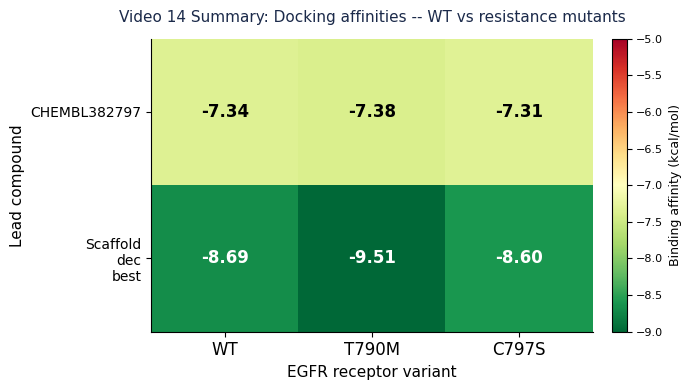

Summary figure saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results/fig4_summary_heatmap.png

VIDEO 14 RESULTS SUMMARY

CHEMBL382797:
  Wild-type  : -7.343 kcal/mol
  T790M      : -7.381 kcal/mol  (delta: -0.038)
  C797S      : -7.314 kcal/mol  (delta: +0.029)

Scaffold_dec_best:
  Wild-type  : -8.686 kcal/mol
  T790M      : -9.513 kcal/mol  (delta: -0.827)
  C797S      : -8.597 kcal/mol  (delta: +0.089)

Negative delta = mutation weakens binding.
Positive delta = compound might handle the mutation.

All results saved to: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video14_mutant_docking/results


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Summary heatmap: docking affinities across all ligand-receptor combinations

lig_names  = list(docking_results.keys())
rec_labels = ["WT", "T790M", "C797S"]

# Build matrix
matrix = np.zeros((len(lig_names), len(rec_labels)))
for i, lig in enumerate(lig_names):
    for j, rec in enumerate(rec_labels):
        val = docking_results[lig].get(rec, 0)
        matrix[i, j] = val if val is not None else 0

fig, ax = plt.subplots(figsize=(7, 4))

im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto", vmin=-9, vmax=-5)

ax.set_xticks(range(len(rec_labels)))
ax.set_xticklabels(rec_labels, fontsize=12)
ax.set_yticks(range(len(lig_names)))
ax.set_yticklabels([l.replace("_", "\n") for l in lig_names], fontsize=10)

# Annotate cells with values
for i in range(len(lig_names)):
    for j in range(len(rec_labels)):
        val = matrix[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if val < -7.5 else "black")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Binding affinity (kcal/mol)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title("Video 14 Summary: Docking affinities -- WT vs resistance mutants",
             fontsize=11, color=NAVY, pad=12)

# Column labels for receptor type
ax.set_xlabel("EGFR receptor variant", fontsize=11)
ax.set_ylabel("Lead compound", fontsize=11)

plt.tight_layout()
fig_path = RESULTS_DIR / "fig4_summary_heatmap.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Summary figure saved to {fig_path}")

# Final text summary
print("\n" + "="*60)
print("VIDEO 14 RESULTS SUMMARY")
print("="*60)
for lig_name in lig_names:
    wt_val    = docking_results[lig_name].get("WT")
    t790m_val = docking_results[lig_name].get("T790M")
    c797s_val = docking_results[lig_name].get("C797S")
    print(f"\n{lig_name}:")
    print(f"  Wild-type  : {wt_val:.3f} kcal/mol")
    print(f"  T790M      : {t790m_val:.3f} kcal/mol  (delta: {t790m_val - wt_val:+.3f})")
    print(f"  C797S      : {c797s_val:.3f} kcal/mol  (delta: {c797s_val - wt_val:+.3f})")
print("\nNegative delta = mutation weakens binding.")
print("Positive delta = compound might handle the mutation.")
print(f"\nAll results saved to: {RESULTS_DIR}")